In [1]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
from datasets import load_dataset, Audio
from IPython.display import Audio as Player, display

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean", streaming=True)
dataset = dataset.cast_column("audio", Audio(decode=False))
sample = next(iter(dataset))

audio = sample["audio"]
source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
y, sr = sf.read(source)
if y.ndim > 1:
    y = y.mean(axis=1)

reference = np.asarray(sample["speech"], dtype=int)        # 1 = speech, 0 = non-speech
valid = np.asarray(sample["confidence"], dtype=int) == 1   # only confident labels are scored
n_blocks = len(y) // LABEL_HOP
assert len(reference) == n_blocks
t = np.arange(len(y)) / sr

print("File:", sample["file"], "| Duration:", round(len(y) / sr, 3), "s | Labels:", n_blocks)

File: 6930-75918-0000.flac | Duration: 3.505 s | Labels: 109


In [3]:
def block_rms(signal):
    """RMS energy of each 512-sample block (same grid as the reference labels)."""
    blocks = signal[:n_blocks * LABEL_HOP].reshape(n_blocks, LABEL_HOP)
    return np.sqrt(np.mean(blocks ** 2, axis=1))

def to_db(values):
    return 20 * np.log10(values + 1e-10)

def metrics(true, pred):
    tp = int(np.sum((true == 1) & (pred == 1))); tn = int(np.sum((true == 0) & (pred == 0)))
    fp = int(np.sum((true == 0) & (pred == 1))); fn = int(np.sum((true == 1) & (pred == 0)))
    miss = fn / (tp + fn) if tp + fn else np.nan          # share of speech that was cut
    fa = fp / (fp + tn) if fp + tn else np.nan            # share of non-speech called speech
    return {"miss_rate": miss, "false_alarm_rate": fa, "balanced_accuracy": 1 - (miss + fa) / 2,
            "TP": tp, "TN": tn, "FP": fp, "FN": fn}

true = reference[valid]
rms_clean = block_rms(y)

In [4]:
# Sample-level mask of the speech regions, built from the reference labels
speech_mask = np.zeros(len(y), dtype=bool)
speech_mask[:n_blocks * LABEL_HOP] = np.repeat(reference == 1, LABEL_HOP)

def make_noise(n, kind, rng):
    """White noise has equal power at all frequencies; pink noise has more power at low frequencies."""
    white = rng.normal(size=n)
    if kind == "white":
        return white
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = freqs[1]                       # avoid division by zero at 0 Hz
    return np.fft.irfft(spectrum / np.sqrt(freqs), n=n)

def add_noise(signal, snr_db, kind="white", seed=0, active_only=True):
    """Add noise at the requested SNR.

    active_only=True measures the speech power only where speech is present.
    active_only=False uses the whole recording, pauses included.
    """
    rng = np.random.default_rng(seed)
    noise = make_noise(len(signal), kind, rng)
    reference_part = signal[speech_mask] if active_only else signal
    signal_power = np.mean(reference_part ** 2)
    noise_power = np.mean(noise ** 2)
    noise = noise * np.sqrt(signal_power / (noise_power * 10 ** (snr_db / 10)))
    return signal + noise

power_active = np.mean(y[speech_mask] ** 2)
power_whole = np.mean(y ** 2)
print("Speech share of the recording:", speech_mask.mean().round(2))
print("Difference between the two SNR definitions:", (10 * np.log10(power_active / power_whole)).round(2), "dB")

Speech share of the recording: 0.75
Difference between the two SNR definitions: 1.24 dB


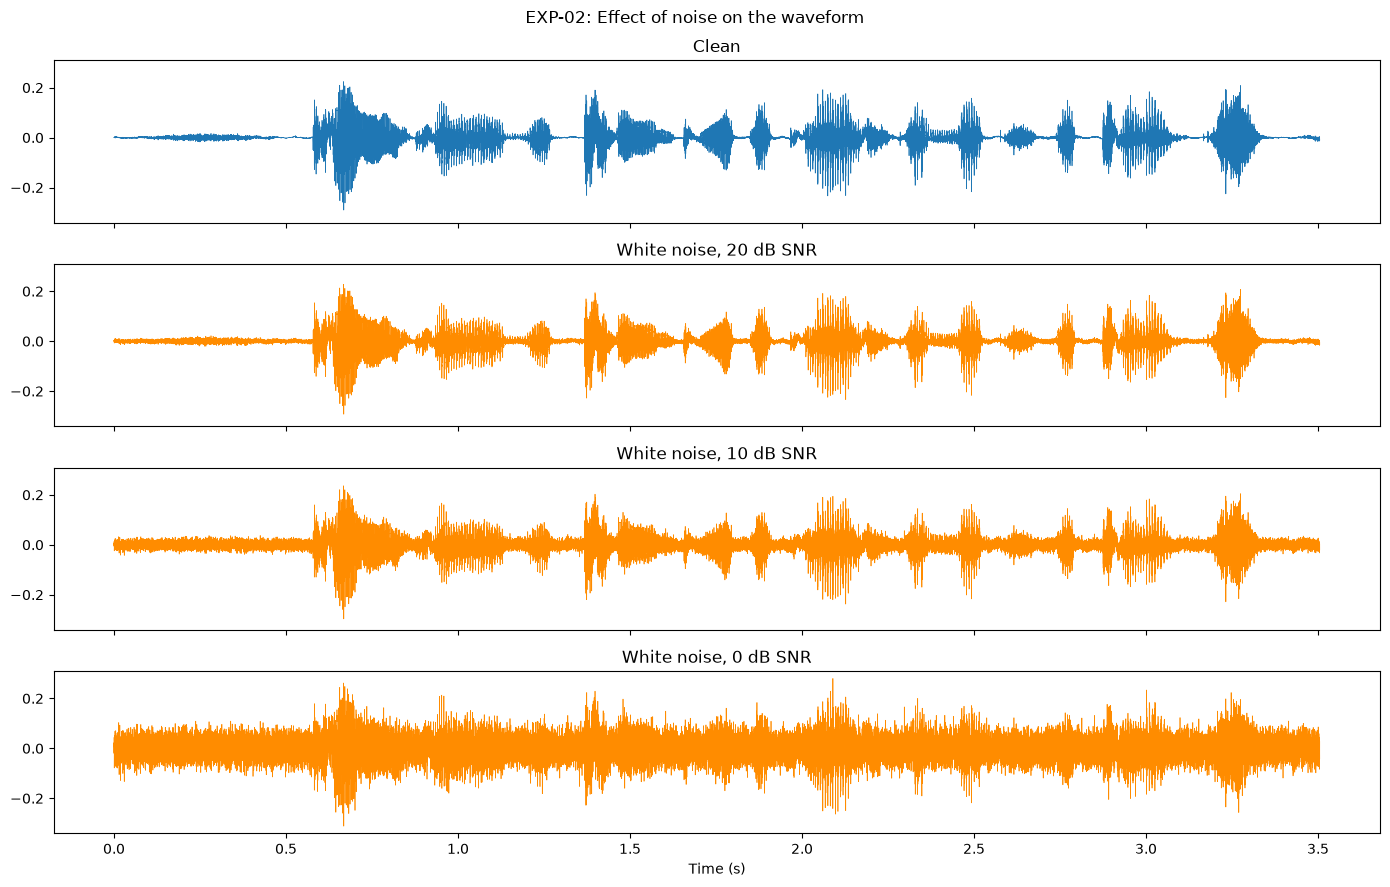

20 dB SNR


10 dB SNR


0 dB SNR


In [5]:
levels = [20, 10, 0]
fig, axes = plt.subplots(len(levels) + 1, 1, figsize=(14, 9), sharex=True, sharey=True)
axes[0].plot(t, y, linewidth=0.5); axes[0].set_title("Clean")
for ax, snr in zip(axes[1:], levels):
    ax.plot(t, add_noise(y, snr), linewidth=0.5, color="darkorange")
    ax.set_title(f"White noise, {snr} dB SNR")
axes[-1].set_xlabel("Time (s)")
plt.suptitle("EXP-02: Effect of noise on the waveform"); plt.tight_layout(); plt.show()

for snr in levels:
    print(f"{snr} dB SNR"); display(Player(add_noise(y, snr), rate=sr))

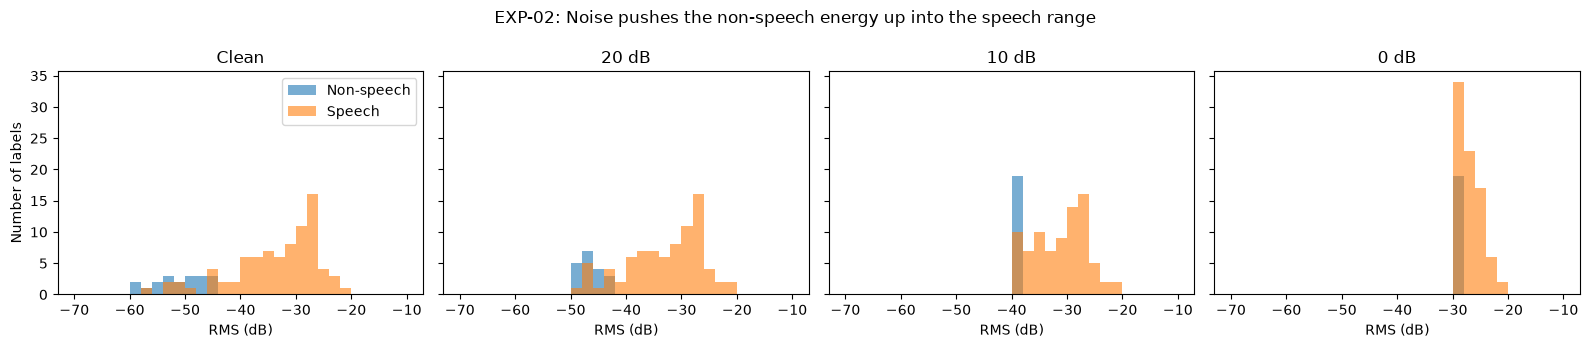

In [6]:
conditions = {"Clean": y, "20 dB": add_noise(y, 20), "10 dB": add_noise(y, 10), "0 dB": add_noise(y, 0)}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharex=True, sharey=True)
bins = np.linspace(-70, -10, 31)
for ax, (name, signal) in zip(axes, conditions.items()):
    db = to_db(block_rms(signal))
    ax.hist(db[valid & (reference == 0)], bins=bins, alpha=0.6, label="Non-speech")
    ax.hist(db[valid & (reference == 1)], bins=bins, alpha=0.6, label="Speech")
    ax.set_title(name); ax.set_xlabel("RMS (dB)")
axes[0].set_ylabel("Number of labels"); axes[0].legend()
plt.suptitle("EXP-02: Noise pushes the non-speech energy up into the speech range")
plt.tight_layout(); plt.show()

In [7]:
def best_threshold(rms_values):
    """Threshold with the highest balanced accuracy. Uses the labels, so it is an upper bound."""
    candidates = np.logspace(-3.5, -0.5, 120)
    scores = [metrics(true, (rms_values[valid] > th).astype(int))["balanced_accuracy"] for th in candidates]
    return candidates[int(np.argmax(scores))]

def adaptive_threshold(rms_values, margin_db=6):
    """Noise floor (10th percentile of the energy) plus a margin. Uses no labels."""
    floor_db = np.percentile(to_db(rms_values), 10)
    return 10 ** ((floor_db + margin_db) / 20)

clean_th = best_threshold(rms_clean)
speech_rms = np.sqrt(power_active)
predicted_break = 20 * np.log10(speech_rms / clean_th)

print(f"Threshold tuned on clean audio: {clean_th:.4f} ({to_db(clean_th):.1f} dB)")
print(f"Speech RMS: {speech_rms:.4f} ({to_db(speech_rms):.1f} dB)")
print(f"Predicted breakdown: the noise alone exceeds the fixed threshold below {predicted_break:.1f} dB SNR")

Threshold tuned on clean audio: 0.0061 (-44.3 dB)
Speech RMS: 0.0339 (-29.4 dB)
Predicted breakdown: the noise alone exceeds the fixed threshold below 14.9 dB SNR


In [8]:
SNRS = [30, 20, 15, 10, 5, 0, -5]
KINDS = ["white", "pink"]
N_SEEDS = 20

rows = []
for kind in KINDS:
    for snr in SNRS:
        for seed in range(N_SEEDS):
            r = block_rms(add_noise(y, snr, kind, seed))
            methods = {
                "fixed (tuned on clean)": clean_th,
                "adaptive (floor + 6 dB)": adaptive_threshold(r),
                "oracle (tuned per condition)": best_threshold(r),
            }
            for method, th in methods.items():
                rows.append({"noise": kind, "snr_db": snr, "seed": seed, "method": method, "threshold": th,
                             **metrics(true, (r[valid] > th).astype(int))})
results = pd.DataFrame(rows)
print("Runs:", len(results))

Runs: 840


In [9]:
white = results[results["noise"] == "white"]
for value in ["miss_rate", "false_alarm_rate", "balanced_accuracy"]:
    print(value)
    display(white.pivot_table(index="method", columns="snr_db", values=value, aggfunc="mean")[SNRS].round(3))

miss_rate


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
adaptive (floor + 6 dB),0.073,0.123,0.199,0.386,0.589,0.938,1.000
fixed (tuned on clean),0.106,0.075,0.005,0.000,0.000,0.000,0.000
oracle (tuned per condition),0.106,0.106,0.115,0.127,0.147,0.259,0.315


false_alarm_rate


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
adaptive (floor + 6 dB),0.245,0.000,0.000,0.0,0.000,0.000,0.000
fixed (tuned on clean),0.000,0.161,0.882,1.0,1.000,1.000,1.000
oracle (tuned per condition),0.000,0.000,0.000,0.0,0.005,0.032,0.105


balanced_accuracy


snr_db,30,20,15,10,5,0,-5
method,,,,,,,
adaptive (floor + 6 dB),0.841,0.938,0.900,0.807,0.705,0.531,0.50
fixed (tuned on clean),0.947,0.882,0.556,0.500,0.500,0.500,0.50
oracle (tuned per condition),0.947,0.947,0.942,0.936,0.924,0.855,0.79


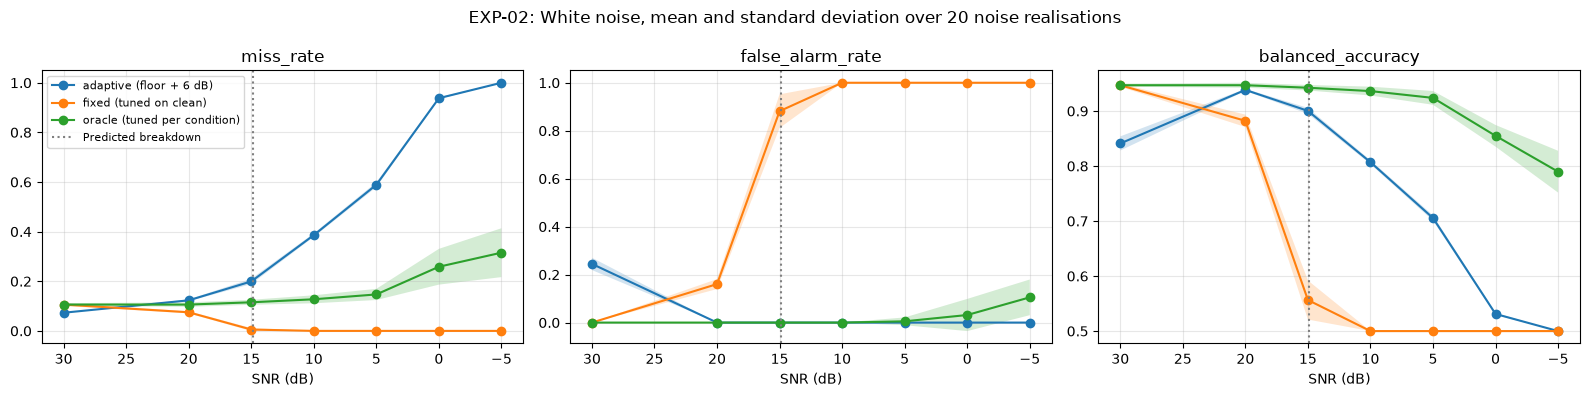

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for ax, value in zip(axes, ["miss_rate", "false_alarm_rate", "balanced_accuracy"]):
    for method, group in white.groupby("method"):
        stats = group.groupby("snr_db")[value].agg(["mean", "std"]).loc[SNRS]
        ax.plot(SNRS, stats["mean"], marker="o", label=method)
        ax.fill_between(SNRS, stats["mean"] - stats["std"], stats["mean"] + stats["std"], alpha=0.2)
    ax.axvline(predicted_break, color="gray", linestyle=":", label="Predicted breakdown")
    ax.set_title(value); ax.set_xlabel("SNR (dB)"); ax.invert_xaxis(); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle("EXP-02: White noise, mean and standard deviation over 20 noise realisations")
plt.tight_layout(); plt.show();

In [11]:
comparison = results[results["method"] != "fixed (tuned on clean)"].pivot_table(
    index=["method", "noise"], columns="snr_db", values="balanced_accuracy", aggfunc="mean")[SNRS]
display(comparison.round(3))

snr_db                                 30     20     15     10     5      0   \
method                       noise                                             
adaptive (floor + 6 dB)      pink   0.838  0.929  0.905  0.835  0.756  0.584   
                             white  0.841  0.938  0.900  0.807  0.705  0.531   
oracle (tuned per condition) pink   0.946  0.943  0.928  0.877  0.806  0.713   
                             white  0.947  0.947  0.942  0.936  0.924  0.855   

snr_db                                -5   
method                       noise         
adaptive (floor + 6 dB)      pink   0.511  
                             white  0.500  
oracle (tuned per condition) pink   0.631  
                             white  0.790

In [12]:
rows = []
for margin in [3, 6, 9, 12]:
    for snr in SNRS:
        for seed in range(N_SEEDS):
            r = block_rms(add_noise(y, snr, "white", seed))
            th = adaptive_threshold(r, margin)
            rows.append({"margin_db": margin, "snr_db": snr, **metrics(true, (r[valid] > th).astype(int))})
margins = pd.DataFrame(rows)
for value in ["miss_rate", "false_alarm_rate"]:
    print(value)
    display(margins.pivot_table(index="margin_db", columns="snr_db", values=value, aggfunc="mean")[SNRS].round(3))

miss_rate


snr_db,30,20,15,10,5,0,-5
margin_db,,,,,,,
3,0.061,0.073,0.122,0.193,0.383,0.594,0.934
6,0.073,0.123,0.199,0.386,0.589,0.938,1.000
9,0.122,0.172,0.329,0.513,0.902,0.998,1.000
12,0.162,0.314,0.470,0.779,0.976,1.000,1.000


false_alarm_rate


snr_db,30,20,15,10,5,0,-5
margin_db,,,,,,,
3,0.474,0.266,0.0,0.0,0.0,0.0,0.0
6,0.245,0.000,0.0,0.0,0.0,0.0,0.0
9,0.000,0.000,0.0,0.0,0.0,0.0,0.0
12,0.000,0.000,0.0,0.0,0.0,0.0,0.0


In [13]:
os.makedirs("../results", exist_ok=True)
summary = results.groupby(["noise", "method", "snr_db"])[["miss_rate", "false_alarm_rate", "balanced_accuracy"]].agg(["mean", "std"])
summary.to_csv("../results/exp02_noise_robustness.csv")
print("Saved.")

Saved.
